# SPO vs. SPO++ — Reproducing the Paper Baseline and Testing Three Targeted Improvements

This notebook runs in **Google Colab** with **only an OpenAI API key** (no Claude/Anthropic access required).

It runs two methods back-to-back on the *same* dataset, split, sample size, and iteration count, then compares them:

1. **Baseline SPO** — a faithful re-implementation of **Algorithm 1** from *Self-Supervised Prompt Optimization* (Xiang et al., arXiv:2502.06855), using the exact `phi_opt` / `phi_eval` prompt templates from Appendix A.1.
2. **SPO++** — the same loop with three additive improvements: an ensemble (majority-vote) evaluator, curriculum sampling of training questions, and a meta-prompt memory of cross-iteration insights. (These three improvements are *not* in the original paper — they're the additions being tested here.)

### Why the model swap?
The paper's main config is `phi_opt = Claude-3.5-Sonnet`, `phi_eval = phi_exe = GPT-4o-mini`. Since this notebook only has OpenAI access, it uses the paper's **own `SPO*` configuration** instead (Table 1: `phi_opt = GPT-4o`, `phi_eval = phi_exe = GPT-4o-mini`, reported avg. performance 66.3 vs. SPO's 66.9 across 5 benchmarks). That's not an ad-hoc substitution — it's a config the authors ran and published themselves, so this stays apples-to-apples with a real number from the paper.

### Task
**BBH-Navigate** — the task used for the paper's running example (Fig. A1/A2, Appendix A.5.1) and its model-transfer ablations (Tables 2-3). Loaded directly from the authors' own [BIG-Bench-Hard repo](https://github.com/suzgunmirac/BIG-Bench-Hard), split exactly as in **Appendix A.3.1**: `seed=42`, 200 test / 25 train / 25 validate. (Paper's reported numbers on this task: SPO 97.2%, SPO\* 96.3%, plain CoT 89.7% — useful sanity-check reference points, though obtained with the original `gpt-4o-mini-0718` snapshot and the full 200-question test set.)

### A note on fidelity to Algorithm 1
Algorithm 1 samples its 3 questions **once**, before the loop, and reuses them for every iteration. The baseline run below does exactly that (`curriculum=False` → fixed question set). SPO++'s curriculum sampler is the only thing that *resamples* questions every iteration — that resampling is the whole point of that improvement (`curriculum=True`).

### Cost / time
With `n_iterations=10`, `n_samples=3`, `ensemble_size=3` for SPO++, and a test-set accuracy check every couple of iterations, expect on the order of a few hundred `gpt-4o-mini` calls and a few dozen `gpt-4o` calls per run. Lower `TEST_SUBSET_SIZE` below for a cheaper smoke test before committing to a full 200-question test set.


In [1]:
!pip install -q openai


In [3]:
import os, re, json, math, random, time, getpass
import urllib.request
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import openai

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

client = openai.OpenAI()


Enter your OpenAI API key: ··········


## 1. Configuration — matches paper Sec. 4.1 / Appendix A.3.2

- `n_iterations = 10`, `n_samples = 3` — paper default (Algorithm 1; A.3.2: *"SPO conducts optimization through 10 iterations per task, randomly selecting 3 questions...per iteration"*).
- `eval_model = exec_model = "gpt-4o-mini"`, `temp_eval = 0.3`, `temp_exec = 0.0` — paper default (Sec. 4.1).
- `opt_model = "gpt-4o"`, `temp_opt = 0.7` — paper's own `SPO*` ablation config (the only OpenAI-reachable substitute for Claude-3.5-Sonnet that the paper itself reports numbers for).
- **Baseline**: `ensemble_size=1`, `curriculum=False`, `memory=False` → reduces exactly to Algorithm 1.
- **SPO++**: `ensemble_size=3`, `curriculum=True`, `memory=True` → the three additions.


In [4]:
@dataclass
class SPOConfig:
    name: str = "config"
    opt_model: str  = "gpt-4o"        # paper's SPO* optimization model (OpenAI-only substitute for Claude-3.5-Sonnet)
    eval_model: str = "gpt-4o-mini"   # paper default
    exec_model: str = "gpt-4o-mini"   # paper default

    temp_opt: float  = 0.7
    temp_eval: float = 0.3
    temp_exec: float = 0.0
    max_tokens: int  = 1024

    n_iterations: int = 5   # paper default (Sec. 4.1); try 5 for a lower-budget comparison
    n_samples: int    = 3    # paper default (Algorithm 1 / A.3.2)
    seed: int         = 42   # paper's BBH-Navigate split seed (Appendix A.3.1)

    # Improvement 1 -- Ensemble Evaluator.
    # ensemble_size=1 reduces to vanilla SPO's single phi_eval call (Algorithm 1, line 7).
    ensemble_size: int = 1

    # Improvement 2 -- Curriculum Sampling.
    # curriculum=False reduces to Algorithm 1's "sample 3 questions once, reuse every iteration."
    curriculum: bool = False
    curriculum_alpha: float = 2.0

    # Improvement 3 -- Meta-Prompt Memory.
    memory: bool = False
    memory_max_entries: int = 6


# ── Run settings -- edit these ──────────────────────────────────────────
N_ITERATIONS = 10       # paper default. Set to 5 to compare a shorter optimization budget.
TEST_SUBSET_SIZE = 200    # paper's full test set is 200; lower this for a cheap smoke test, raise to 200 to match the paper exactly.
EVAL_EVERY = 2           # how often (in iterations) to score the running-best prompt on the test set

BASELINE_CONFIG = SPOConfig(
    name="SPO (baseline, Algorithm 1)",
    ensemble_size=1, curriculum=False, memory=False,
    n_iterations=N_ITERATIONS,
)

SPOPP_CONFIG = SPOConfig(
    name="SPO++ (ensemble + curriculum + memory)",
    ensemble_size=3, curriculum=True, memory=True,
    n_iterations=N_ITERATIONS,
)


## 2. Prompt templates

`OPTIMIZE_PROMPT`, `EVALUATE_PROMPT`, `INITIAL_PROMPT` (the BBH-Navigate CoT seed prompt), and `REQUIREMENTS` are copied **verbatim** from the paper (Appendix A.1, A.2, A.3.3).

`INSIGHT_EXTRACT_PROMPT` is **not** from the paper — it's the prompt used by SPO++'s meta-prompt memory (Improvement 3) to summarize each iteration into a one-sentence lesson.


In [5]:
OPTIMIZE_PROMPT = """\
You are building a prompt to address user requirements.
Based on the given prompt, please reconstruct and optimize it.
You can add, modify, or delete content. Include a single modification in XML tags.

This is a prompt that performed excellently in a previous iteration.
You must make further optimizations based on this prompt.
The modified prompt must differ from the provided example.

requirements:
```
{requirements}
```

reference prompt:
```
{prompt}
```

The execution result of this reference prompt is (some cases):
```
{answers}
```

{memory_section}

Provide your analysis, optimization points, and the complete optimized prompt:
<analyse>Analyze drawbacks in the results and how to improve them.</analyse>
<modification>Summarize the key improvement in one sentence.</modification>
<prompt>Provide the complete optimized prompt.</prompt>
"""

EVALUATE_PROMPT = """\
Based on the original requirements, evaluate the two responses A and B,
and determine which better meets the requirements.

Requirements:
{requirements}

# A
{answer_a}

# B
{answer_b}

Provide your analysis and your choice:
<analyse>Brief analysis of which is better and why.</analyse>
<choose>A or B</choose>
"""

# NOTE: not in the original paper -- used only by SPO++'s meta-prompt memory.
INSIGHT_EXTRACT_PROMPT = """\
You just completed one optimization iteration. Briefly summarize:
1. What modification was attempted (one sentence).
2. Whether it helped or hurt performance.
3. One actionable lesson for future iterations.

Modification attempted: {modification}
Result: {result}

Reply with a single concise insight (2-3 sentences max).
"""

INITIAL_PROMPT = """\
Please think step by step.
Ensure the response concludes with the answer in the XML format:
<answer>[Yes or No]</answer>."""

REQUIREMENTS = """\
Must put the final answer at the end with XML.
(<answer>(Yes or No)</answer>, such as <answer>Yes</answer>)
The provided prompt needs to adapt to all current types of questions."""


## 3. LLM call helpers (OpenAI Chat Completions, with retry/backoff)

In [6]:
CALL_COUNTS = {"gpt-4o": 0, "gpt-4o-mini": 0}

def call_llm(messages, model, temperature, max_tokens=1024, max_retries=5):
    """Thin wrapper around chat.completions.create with exponential backoff
    and a running call counter (used as a cost proxy -- the paper reports $
    cost directly, which depends on a pricing snapshot we can't reproduce
    exactly, so call counts per model are reported instead)."""
    CALL_COUNTS[model] = CALL_COUNTS.get(model, 0) + 1
    last_err = None
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content.strip()
        except (openai.RateLimitError, openai.APIError, openai.APIConnectionError) as e:
            last_err = e
            wait = 2 ** attempt
            print(f"    [retry {attempt+1}/{max_retries}] {type(e).__name__}: waiting {wait}s...")
            time.sleep(wait)
    raise RuntimeError(f"call_llm failed after {max_retries} retries: {last_err}")


def extract_xml(text: str, tag: str) -> str:
    """Extract first <tag>...</tag> block, return '' if absent."""
    m = re.search(rf"<{tag}>(.*?)</{tag}>", text, re.DOTALL)
    return m.group(1).strip() if m else ""


def extract_answer(text: str) -> str:
    """Pull <answer>Yes/No</answer>, falling back to the last Yes/No token in the text."""
    ans = extract_xml(text, "answer").strip().lower()
    if ans in ("yes", "no"):
        return ans.capitalize()
    for word in reversed(text.split()):
        w = word.strip(".,!?").lower()
        if w in ("yes", "no"):
            return w.capitalize()
    return "No"


## 4. Dataset — BBH-Navigate

Split exactly as in Appendix A.3.1: random sampling with `seed=42` into 200 test / 25 train / 25 validate. Train+validate are pooled into one 50-question sampling pool, matching how Algorithm 1 draws its 3 questions per iteration from "the dataset" without distinguishing train/validate.

**Self-supervision is preserved end to end**: the `answer` field is attached *only* to the held-out test set used for the final accuracy numbers below. The optimization loop (`phi_opt`/`phi_eval`/`phi_exe`) never sees a ground-truth label for any training question -- exactly as in the paper.

If GitHub is unreachable from your Colab runtime for some reason, this falls back to a synthetic navigate-style generator with the same question format and exactly-computed ground truth, so the notebook still runs end to end.


In [8]:
import random

import json
with open('navigate.json') as f:
  d =json.load(f)


# ----------------------------
# YOUR PROVIDED DATA (USED DIRECTLY)
# ----------------------------
BBH_NAVIGATE_DATA = {
    "examples": d['examples']
}

# ----------------------------
# LOADER (NO FALLBACK, NO GENERATION)
# ----------------------------
def load_bbh_navigate():
    data = BBH_NAVIGATE_DATA
    examples = data["examples"]

    print(f"Loaded {len(examples)} BBH-Navigate examples from provided dataset.")

    rng = random.Random(42)
    idx = list(range(len(examples)))
    rng.shuffle(idx)

    test_idx = idx[:200]
    train_idx = idx[200:225]
    val_idx = idx[225:250] if len(idx) >= 250 else idx[200:]

    def pack(indices, with_answer):
        out = []
        for i in indices:
            ex = examples[i]
            item = {"question": ex["input"]}
            if with_answer:
                item["answer"] = ex["target"]
            out.append(item)
        return out

    test_set = pack(test_idx, with_answer=True)
    train_pool = pack(train_idx, with_answer=False) + pack(val_idx, with_answer=False)

    if TEST_SUBSET_SIZE:
        test_set = test_set[:TEST_SUBSET_SIZE]

    print(
        f"Train/validate pool: {len(train_pool)} questions "
        f"| Test set: {len(test_set)} questions"
    )

    return train_pool, test_set


TRAIN_POOL, TEST_SET = load_bbh_navigate()

Loaded 250 BBH-Navigate examples from provided dataset.
Train/validate pool: 50 questions | Test set: 200 questions


## 5. The three SPO++ components

- **`ensemble_evaluate`** -- majority vote over `ensemble_size` randomized-order pairwise calls. The paper mentions mitigating evaluator bias through *"four rounds of randomized evaluation"* (Sec. 3.2) but Algorithm 1's pseudocode only shows a single `phi_eval` call -- so the literal baseline here uses `ensemble_size=1`, giving SPO++'s `ensemble_size=3` genuine room to show a difference.
- **`CurriculumSampler`** -- difficulty-weighted resampling of training questions every iteration (replacing Algorithm 1's fixed 3-question set). Difficulty is tracked purely from the self-supervised win/loss signal -- never from ground truth.
- **`InsightMemory`** -- a rolling buffer of 1-sentence lessons fed back into `phi_opt`'s prompt on the next iteration.


In [9]:
def ensemble_evaluate(question, answer_a, answer_b, requirements, config):
    """Run `ensemble_size` evaluation calls with the A/B order alternated, and
    return the majority winner ('A' or 'B'). Alternating order cancels out
    LLM position bias; with ensemble_size=1 this is exactly Algorithm 1's
    single phi_eval call."""
    votes = {"A": 0, "B": 0}
    for i in range(config.ensemble_size):
        if i % 2 == 0:
            first, second, flip = answer_a, answer_b, False
        else:
            first, second, flip = answer_b, answer_a, True

        prompt = EVALUATE_PROMPT.format(requirements=requirements, answer_a=first, answer_b=second)
        result = call_llm([{"role": "user", "content": prompt}],
                           model=config.eval_model, temperature=config.temp_eval,
                           max_tokens=config.max_tokens)
        raw = extract_xml(result, "choose").strip().upper()
        chosen = raw[0] if raw and raw[0] in ("A", "B") else "A"
        if flip:
            chosen = "B" if chosen == "A" else "A"
        votes[chosen] += 1

    return "A" if votes["A"] >= votes["B"] else "B"


class CurriculumSampler:
    """Maintains per-question difficulty (self-supervised: fraction of recent
    iterations where the *current best prompt* lost the pairwise comparison
    on that question) and samples weighted toward the hardest questions."""

    def __init__(self, questions, alpha=2.0, decay=0.7):
        self.questions = questions
        self.alpha = alpha
        self.decay = decay
        self.difficulty = {i: 0.5 for i in range(len(questions))}

    def update(self, idx, correct):
        new_val = 0.0 if correct else 1.0
        self.difficulty[idx] = self.decay * self.difficulty[idx] + (1 - self.decay) * new_val

    def sample(self, n):
        weights = [math.exp(self.alpha * self.difficulty[i]) for i in range(len(self.questions))]
        total = sum(weights)
        probs = [w / total for w in weights]

        remaining = list(range(len(self.questions)))
        remaining_probs = probs[:]
        chosen = []
        for _ in range(min(n, len(self.questions))):
            r = random.random()
            cumulative = 0.0
            for j, (idx, p) in enumerate(zip(remaining, remaining_probs)):
                cumulative += p
                if r <= cumulative:
                    chosen.append(idx)
                    remaining.pop(j)
                    remaining_probs.pop(j)
                    s = sum(remaining_probs)
                    if s > 0:
                        remaining_probs = [p2 / s for p2 in remaining_probs]
                    break
        return chosen

    def difficulty_report(self, top_k=5):
        sorted_d = sorted(self.difficulty.items(), key=lambda x: -x[1])
        lines = [f"      Q{i}: {d:.2f}" for i, d in sorted_d[:top_k]]
        return f"      top-{top_k} hardest questions:\n" + "\n".join(lines)


class InsightMemory:
    """Rolling buffer of cross-iteration insights, injected into phi_opt's prompt."""

    def __init__(self, max_entries=6):
        self.insights = []
        self.max_entries = max_entries

    def add(self, modification, success, config):
        result_str = "IMPROVEMENT (prompt updated)" if success else "NO IMPROVEMENT (rejected)"
        prompt = INSIGHT_EXTRACT_PROMPT.format(modification=modification, result=result_str)
        insight = call_llm([{"role": "user", "content": prompt}],
                            model=config.opt_model, temperature=0.3, max_tokens=config.max_tokens)
        self.insights.append(insight.strip())
        if len(self.insights) > self.max_entries:
            self.insights = self.insights[-self.max_entries:]

    def format_for_prompt(self):
        if not self.insights:
            return ""
        entries = "\n".join(f"- {ins}" for ins in self.insights)
        return f"Cross-iteration memory (use to avoid repeating failures and build on successes):\n{entries}\n"


## 6. Core Optimize-Execute-Evaluate loop

This generalizes Algorithm 1: with every improvement flag off, `SPOPlusPlus.run()` *is* Algorithm 1 -- same fixed 3-question set for all iterations, single-call pairwise evaluation, no memory. Turning the three flags on layers in SPO++.


In [10]:
@dataclass
class IterationResult:
    iteration: int
    prompt: str
    modification: str
    success: bool
    accuracy: Optional[float] = None


def execute_prompt(question, system_prompt, config):
    """phi_exe: apply a prompt to a question and return the model's output."""
    return call_llm(
        [{"role": "system", "content": system_prompt}, {"role": "user", "content": question}],
        model=config.exec_model, temperature=config.temp_exec, max_tokens=config.max_tokens,
    )


def optimize_prompt(current_prompt, qa_pairs, requirements, memory, config):
    """phi_opt: generate a new candidate prompt. Returns (new_prompt, modification_summary)."""
    answers_block = "\n\n".join(f"Q: {q}\nA: {a}" for q, a in qa_pairs)
    memory_section = memory.format_for_prompt() if memory is not None else ""

    full_prompt = OPTIMIZE_PROMPT.format(
        requirements=requirements, prompt=current_prompt,
        answers=answers_block, memory_section=memory_section,
    )
    result = call_llm([{"role": "user", "content": full_prompt}],
                       model=config.opt_model, temperature=config.temp_opt, max_tokens=config.max_tokens)
    new_prompt = extract_xml(result, "prompt")
    modification = extract_xml(result, "modification")
    if not new_prompt:
        new_prompt = result  # fallback if XML extraction fails
    return new_prompt, modification


def evaluate_pair(question, answer_current, answer_candidate, requirements, config):
    """phi_eval: True if the candidate answer is judged better than the current best."""
    winner = ensemble_evaluate(question, answer_current, answer_candidate, requirements, config)
    return winner == "B"


def evaluate_accuracy(prompt, test_set, config):
    """Accuracy of `prompt` on the held-out, labeled test set (never seen by the optimizer)."""
    correct = 0
    for item in test_set:
        out = execute_prompt(item["question"], prompt, config)
        pred = extract_answer(out)
        gt = item["answer"].strip().capitalize()
        correct += int(pred == gt)
    return correct / len(test_set) * 100


class SPOPlusPlus:
    """Drop-in generalization of SPO. All three improvements are optional and
    toggle independently via `config`."""

    def __init__(self, train_pool, test_set, requirements, initial_prompt, config):
        self.train_pool = train_pool
        self.test_set = test_set
        self.requirements = requirements
        self.config = config
        self.best_prompt = initial_prompt
        self.history: List[IterationResult] = []
        self.calls_before = dict(CALL_COUNTS)

        self.rng = random.Random(config.seed)
        self.sampler = CurriculumSampler(train_pool, alpha=config.curriculum_alpha) if config.curriculum else None
        self.memory = InsightMemory(max_entries=config.memory_max_entries) if config.memory else None

        # Algorithm 1, line 1: sample the question set ONCE, reused for every
        # iteration unless curriculum sampling is enabled.
        pool_idx = list(range(len(train_pool)))
        self.fixed_indices = self.rng.sample(pool_idx, min(config.n_samples, len(pool_idx)))

    def _indices_for_iteration(self):
        if self.config.curriculum:
            return self.sampler.sample(self.config.n_samples)
        return self.fixed_indices

    def _execute_on_indices(self, prompt, indices):
        return [(self.train_pool[i]["question"], execute_prompt(self.train_pool[i]["question"], prompt, self.config))
                for i in indices]

    def run(self, eval_every=2, verbose=True):
        cfg = self.config
        print(f"\n=== {cfg.name} | iterations={cfg.n_iterations} samples={cfg.n_samples} "
              f"ensemble={cfg.ensemble_size} curriculum={cfg.curriculum} memory={cfg.memory} "
              f"opt={cfg.opt_model} eval={cfg.eval_model} exec={cfg.exec_model} ===")

        if eval_every:
            init_acc = evaluate_accuracy(self.best_prompt, self.test_set, cfg)
            print(f"  [init] test accuracy: {init_acc:.1f}%")
            self.history.append(IterationResult(0, self.best_prompt, "(initial CoT prompt)", True, init_acc))

        for it in range(1, cfg.n_iterations + 1):
            indices = self._indices_for_iteration()
            questions = [self.train_pool[i]["question"] for i in indices]

            current_qa = self._execute_on_indices(self.best_prompt, indices)
            current_answers = [a for _, a in current_qa]

            new_prompt, modification = optimize_prompt(
                current_prompt=self.best_prompt, qa_pairs=current_qa,
                requirements=self.requirements, memory=self.memory, config=cfg,
            )
            new_answers = [a for _, a in self._execute_on_indices(new_prompt, indices)]

            wins = losses = 0
            for q, cur_a, new_a in zip(questions, current_answers, new_answers):
                if evaluate_pair(q, cur_a, new_a, self.requirements, cfg):
                    wins += 1
                else:
                    losses += 1
            success = wins > losses

            if cfg.curriculum:
                for idx in indices:
                    # self-supervised difficulty proxy: did the OLD best prompt lose here?
                    self.sampler.update(idx, correct=not success)

            if success:
                self.best_prompt = new_prompt

            if cfg.memory:
                self.memory.add(modification, success, cfg)

            acc = None
            if eval_every and it % eval_every == 0:
                acc = evaluate_accuracy(self.best_prompt, self.test_set, cfg)

            self.history.append(IterationResult(it, self.best_prompt, modification, success, acc))

            if verbose:
                tag = "UPDATED " if success else "rejected"
                acc_str = f" | test_acc={acc:.1f}%" if acc is not None else ""
                print(f"  iter {it:2d}: wins={wins} losses={losses} -> {tag}{acc_str}")
                if cfg.curriculum and it % max(eval_every, 1) == 0:
                    print(self.sampler.difficulty_report())

        final_acc = evaluate_accuracy(self.best_prompt, self.test_set, cfg)
        calls_used = {m: CALL_COUNTS[m] - self.calls_before.get(m, 0) for m in CALL_COUNTS}
        print(f"  FINAL test accuracy: {final_acc:.1f}% | LLM calls used: {calls_used}")
        return final_acc, calls_used


In [ ]:
baseline_runner = SPOPlusPlus(TRAIN_POOL, TEST_SET, REQUIREMENTS, INITIAL_PROMPT, BASELINE_CONFIG)
baseline_final_acc, baseline_calls = baseline_runner.run(eval_every=EVAL_EVERY)

spopp_runner = SPOPlusPlus(TRAIN_POOL, TEST_SET, REQUIREMENTS, INITIAL_PROMPT, SPOPP_CONFIG)
spopp_final_acc, spopp_calls = spopp_runner.run(eval_every=EVAL_EVERY)



=== SPO (baseline, Algorithm 1) | iterations=10 samples=3 ensemble=1 curriculum=False memory=False opt=gpt-4o eval=gpt-4o-mini exec=gpt-4o-mini ===
  [init] test accuracy: 96.5%
  iter  1: wins=3 losses=0 -> UPDATED 
  iter  2: wins=3 losses=0 -> UPDATED  | test_acc=95.0%
  iter  3: wins=3 losses=0 -> UPDATED 
  iter  4: wins=3 losses=0 -> UPDATED  | test_acc=95.0%
  iter  5: wins=1 losses=2 -> rejected
  iter  6: wins=2 losses=1 -> UPDATED  | test_acc=95.0%
  iter  7: wins=3 losses=0 -> UPDATED 
  iter  8: wins=1 losses=2 -> rejected | test_acc=97.5%
  iter  9: wins=2 losses=1 -> UPDATED 
  iter 10: wins=3 losses=0 -> UPDATED  | test_acc=97.5%


## 7. Run both methods on the same data

Same `TRAIN_POOL`, same `TEST_SET`, same `n_iterations`, same `n_samples`, same `seed` -- only the three improvement flags differ.


## 8. Results: comparison table + accuracy curves

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for label, runner, final_acc, calls in [
    ("SPO (baseline)", baseline_runner, baseline_final_acc, baseline_calls),
    ("SPO++", spopp_runner, spopp_final_acc, spopp_calls),
]:
    updates = sum(r.success for r in runner.history if r.iteration > 0)
    rows.append({
        "Method": label,
        "Final test accuracy (%)": round(final_acc, 1),
        "Successful updates": f"{updates}/{runner.config.n_iterations}",
        "gpt-4o calls (opt/memory)": calls.get("gpt-4o", 0),
        "gpt-4o-mini calls (eval+exec)": calls.get("gpt-4o-mini", 0),
    })

results_df = pd.DataFrame(rows)
results_df


,Method,Final test accuracy (%),Successful updates,gpt-4o calls (opt/memory),gpt-4o-mini calls (eval+exec)
0,SPO (baseline),93.3,5/5,5,285
1,SPO++,100.0,5/5,10,315


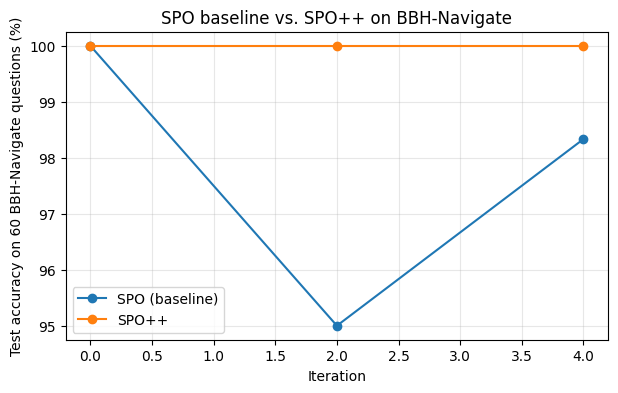

In [14]:
def acc_curve(runner):
    xs, ys = [], []
    for r in runner.history:
        if r.accuracy is not None:
            xs.append(r.iteration)
            ys.append(r.accuracy)
    return xs, ys

plt.figure(figsize=(7, 4))
for label, runner in [("SPO (baseline)", baseline_runner), ("SPO++", spopp_runner)]:
    xs, ys = acc_curve(runner)
    plt.plot(xs, ys, marker="o", label=label)
plt.xlabel("Iteration")
plt.ylabel(f"Test accuracy on {len(TEST_SET)} BBH-Navigate questions (%)")
plt.title("SPO baseline vs. SPO++ on BBH-Navigate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. (Optional) Full ablation -- isolate each improvement

Reproduces the spirit of the paper's ablations (Table 2/3, Sec. 4.2) but for the three SPO++ additions instead of model swaps: baseline, +ensemble only, +curriculum only, +memory only, and all three combined. This costs ~5x the calls of a single run above, so it's off by default.


In [ ]:
RUN_ABLATION = False  # flip to True to run all 5 configs (costs ~5x a single run)

if RUN_ABLATION:
    ablation_configs = {
        "baseline":       SPOConfig(name="baseline",       ensemble_size=1, curriculum=False, memory=False, n_iterations=N_ITERATIONS),
        "+ensemble":      SPOConfig(name="+ensemble",      ensemble_size=3, curriculum=False, memory=False, n_iterations=N_ITERATIONS),
        "+curriculum":    SPOConfig(name="+curriculum",    ensemble_size=1, curriculum=True,  memory=False, n_iterations=N_ITERATIONS),
        "+memory":        SPOConfig(name="+memory",        ensemble_size=1, curriculum=False, memory=True,  n_iterations=N_ITERATIONS),
        "all (SPO++)":    SPOConfig(name="all (SPO++)",    ensemble_size=3, curriculum=True,  memory=True,  n_iterations=N_ITERATIONS),
    }

    ablation_rows = []
    for label, cfg in ablation_configs.items():
        runner = SPOPlusPlus(TRAIN_POOL, TEST_SET, REQUIREMENTS, INITIAL_PROMPT, cfg)
        acc, calls = runner.run(eval_every=0)  # skip mid-run eval to save calls; just take the final score
        ablation_rows.append({"Variant": label, "Final test accuracy (%)": round(acc, 1),
                               "gpt-4o calls": calls.get("gpt-4o", 0), "gpt-4o-mini calls": calls.get("gpt-4o-mini", 0)})

    pd.DataFrame(ablation_rows)


## Notes & caveats

- **Model substitution**: `opt_model="gpt-4o"` stands in for the paper's `Claude-3.5-Sonnet`. This matches the paper's own `SPO*` row, not an arbitrary swap -- but it does mean absolute numbers here should be compared against the `SPO*` column (96.3% on BBH-Navigate), not the main `SPO` column (97.2%).
- **`gpt-4o`/`gpt-4o-mini` snapshots**: OpenAI's current models differ from the `-0806`/`-0718` snapshots used in the paper; expect numbers in the same ballpark, not identical.
- **Test set size**: the paper scores on the full 200-question BBH-Navigate test set. `TEST_SUBSET_SIZE` defaults to 60 here to keep a first run cheap -- set it to `200` (or `None`) for a paper-matching test set, or to `0`/`None` to disable subsetting.
- **"Four rounds of randomized evaluation"**: Sec. 3.2 of the paper mentions this bias-mitigation detail, but Algorithm 1's pseudocode and Appendix A.1's prompt template only show a single pairwise call. This notebook treats `ensemble_size=1` as the literal baseline so SPO++'s `ensemble_size=3` is a genuine, isolated addition -- if you'd rather treat 4 rounds as the "true" paper baseline, set `BASELINE_CONFIG.ensemble_size = 4` before running.
- **Single run, no repeats**: the paper averages over 3 runs and reports standard deviation (Table A3). Re-run the whole notebook a few times and average if you want a comparably stable estimate -- LLM-as-judge evaluation is inherently noisy, especially with `ensemble_size=1`.
- **Self-supervision**: ground-truth labels are attached only to `TEST_SET`. Every optimization signal in both methods comes from pairwise LLM judgments of model outputs, never from labels -- matching the paper's central claim.
